## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
Already up to date.


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [15]:
import os
import pandas as pd
from xgboost import XGBRanker
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score

from Challenge.paths import load_xgboost_cv_folds, XGBOOST_DATAFRAMES
from Challenge.utils import XGBoostRerankerRecommender, evaluate_recommender

## **Load Data**

In [4]:
_, URM_outer, _ = load_xgboost_cv_folds()
del _

In [5]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "training_data.parquet")

X_train = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_train

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/training_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,5609,False,0.270185,116,0,0.428426,133,0,0.415858,...,410.333344,1341.456177,4.480386,20.308155,0.292546,0.234324,0.334969,2.938539,58,2319
1,0,1940,False,0.612331,7,1,0.632690,26,0,0.494830,...,735.333313,1595.107910,2.655794,6.240859,0.406598,0.335242,-0.084116,-1.069763,60,5214
2,0,3258,True,0.078685,762,0,0.342990,255,0,0.113605,...,319.952393,688.967896,4.085459,17.637278,0.266451,0.218058,1.866132,4.445840,60,670
3,0,1504,True,0.013036,2678,0,0.349408,241,0,0.153183,...,675.000000,992.564087,1.595576,1.127617,0.228266,0.229798,1.721957,2.795686,60,111
4,0,3754,False,0.070346,845,0,0.350854,236,0,0.162925,...,455.380951,1009.099426,4.265712,18.893778,0.212713,0.210222,2.275531,7.895197,60,599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18951167,27094,5710,False,0.133869,367,0,0.234847,412,0,0.129152,...,1057.380981,1446.436890,1.583079,0.779230,0.199828,0.216875,2.181109,6.204274,203,1149
18951168,27094,922,False,0.002680,5233,0,0.016180,3255,0,0.000000,...,3547.619141,1631.819336,-1.073892,0.218229,0.032714,0.203449,3.166867,13.133365,203,23
18951169,27094,2879,False,0.002214,5769,0,0.044773,1989,0,0.000000,...,3002.523926,1880.761597,0.123180,-1.063256,0.065779,0.187186,3.228773,12.709620,203,19
18951170,27094,6584,False,0.411395,32,0,0.108802,1067,0,0.000000,...,2719.095215,2221.630859,0.494051,-1.043575,0.081124,0.232286,2.912767,10.398072,203,3531


In [6]:
if not X_train['UserID'].is_monotonic_increasing:
    print("⚠️ Data is NOT sorted by UserID.")
    print("Sorting and overwriting file for future efficiency...")
    
    # Sort and reset index (critical for contiguous memory in ML)
    X_train = X_train.sort_values(by='UserID').reset_index(drop=True)
    
    # Overwrite the file on disk
    X_train.to_parquet(
        path=file_path,
        engine='fastparquet',
        compression='zstd',
        index=False
    )
    
    print(f"✅ Data sorted and saved to {file_path}")

In [7]:
assert X_train['UserID'].is_monotonic_increasing, "UserID column is not sorted in increasing order!"

# Group Calculation
groups = X_train.groupby("UserID").size().values

# Target and Feature Matrix Definition
y_train = X_train["Label"]

# Drop the identifiers (UserID, ItemID) and the target (Label), keeping only the features
X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore') 

assert groups.sum() == X_train.shape[0], "Group sum does not match total data size!"

In [14]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "validation_data.parquet")

X_val = pd.read_parquet(
    file_path,
    engine='fastparquet'
)

print(f"Loaded successfully from: {file_path}")
X_val

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/validation_data.parquet


,UserID,ItemID,Label,TopPop_Score,TopPop_RankPosition,TopPop_Recommended,ItemKNN_cosine_Score,ItemKNN_cosine_RankPosition,ItemKNN_cosine_Recommended,ItemKNN_jaccard_Score,...,Mean_RankPosition,Std_RankPosition,Skew_RankPosition,Kurtosis_RankPosition,Mean_Score,Std_Score,Skew_Score,Kurtosis_Score,User_Profile_Len,Item_Global_Popularity
0,0,6411,False,0.081851,717,0,0.701361,5,1,0.681310,...,407.142853,1399.072754,4.281490,18.897297,0.447156,0.278489,-1.061027,3.246427,80,874
1,0,2168,False,0.078760,750,0,0.540989,40,0,0.491260,...,358.047607,936.414124,3.650616,14.062557,0.333984,0.222666,0.733968,1.210770,80,841
2,0,6098,True,0.082225,713,0,0.708915,3,1,0.740307,...,124.571426,279.955811,2.169494,3.165847,0.503251,0.205144,0.271329,0.168902,80,878
3,0,3049,False,0.128114,412,0,0.693846,6,1,0.457670,...,321.095245,918.941772,4.353480,19.441338,0.310892,0.245103,0.985542,0.890398,80,1368
4,0,2399,False,0.442124,27,0,0.639774,15,1,0.261722,...,362.523804,1433.629395,4.515592,20.544024,0.405237,0.275703,-1.123605,4.698762,80,4721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3756433,27094,4180,False,0.367297,48,0,0.042708,2024,0,0.000000,...,3173.142822,2376.120117,0.292561,-1.572491,0.066819,0.232602,3.163013,11.877620,250,3922
3756434,27094,3236,False,0.593651,8,1,0.194622,524,0,0.114155,...,2111.714355,2253.487793,1.051186,-0.458617,0.134725,0.246047,2.432874,6.639362,250,6339
3756435,27094,4615,False,0.004402,4126,0,0.144729,767,0,0.037827,...,1697.571411,1721.538208,1.812891,2.658815,0.099026,0.205823,2.965396,11.336728,250,47
3756436,27094,6584,False,0.412343,31,0,0.112825,1005,0,0.000000,...,2309.666748,1955.347290,0.944244,-0.389569,0.105150,0.219539,3.446590,12.917460,250,4403


## **Train Baseline**

In [10]:
# Hyperparameters (Your baseline configuration)
n_estimators = 50
learning_rate = 1e-1
reg_alpha = 1e-1
reg_lambda = 1e-1
max_depth = 5
grow_policy = "depthwise"
objective = "pairwise" 

XGB_model = XGBRanker(objective='rank:{}'.format(objective),
                      n_estimators = int(n_estimators),
                      random_state = 42, # Fixed seed for reproducibility
                      learning_rate = learning_rate,
                      reg_alpha = reg_alpha,
                      reg_lambda = reg_lambda,
                      max_depth = int(max_depth),
                      max_leaves = 0,
                      grow_policy = grow_policy,
                      verbosity = 1, # Set to 1 to see training progress
                      booster = "gbtree",
                      n_jobs=-1 # Use all cores
                      )

In [11]:
print(f"Starting XGBRanker training with {len(groups)} user groups...")

XGB_model.fit(X_train,
              y_train,
              group=groups,
              verbose=True)

Starting XGBRanker training with 27095 user groups...


,objective,'rank:pairwise'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## **Score**

In [12]:
# Evaluate training performance
y_pred_scores = XGB_model.predict(X_train)
auc_score = roc_auc_score(y_train, y_pred_scores)
print(f"Training AUC Score: {auc_score:.4f}")

Training AUC Score: 0.7820


In [16]:
# Instantiate the recommender with the trained XGB model
recommender_instance = XGBoostRerankerRecommender(
    XGB_model=XGB_model,
    df=X_val
)
    
# Evaluate
score = evaluate_recommender(recommender_instance, at=20, URM_validation=URM_outer)
print(f"Validation Score (RECALL@20): {score:.4f}")

Eval Batches: 100%|██████████| 28/28 [00:02<00:00, 13.23it/s]

Validation Score (RECALL@20): 0.2911


## **Plots**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

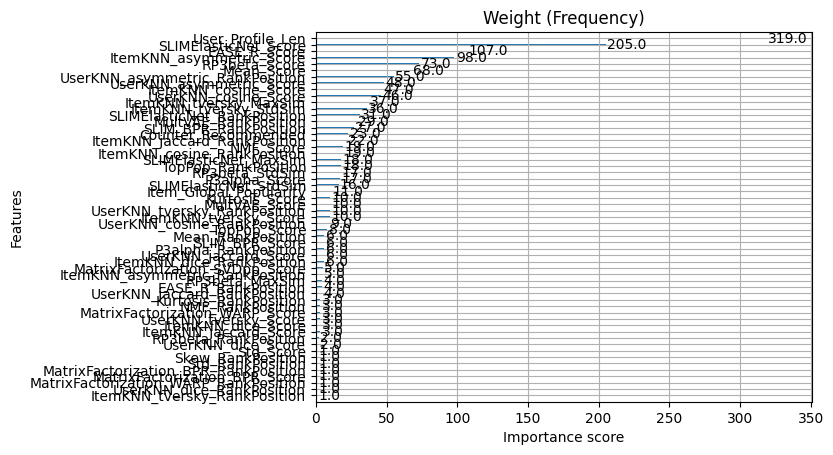

In [17]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

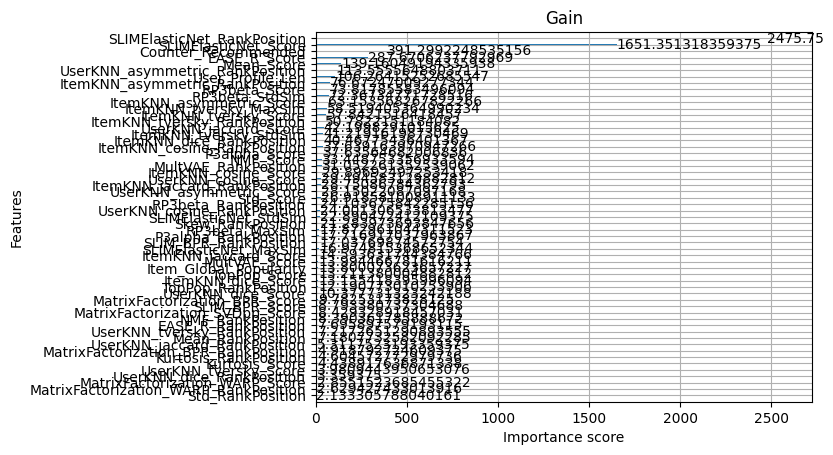

In [18]:
plot_importance(XGB_model, importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

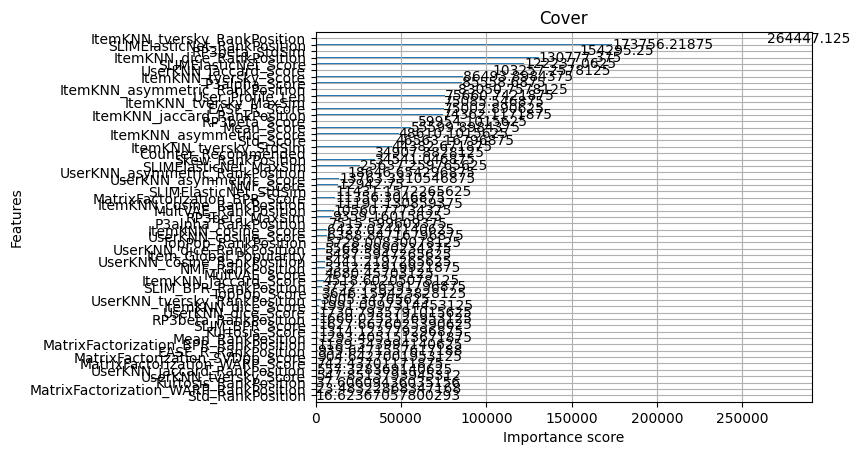

In [19]:
plot_importance(XGB_model, importance_type='cover', title='Cover')

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

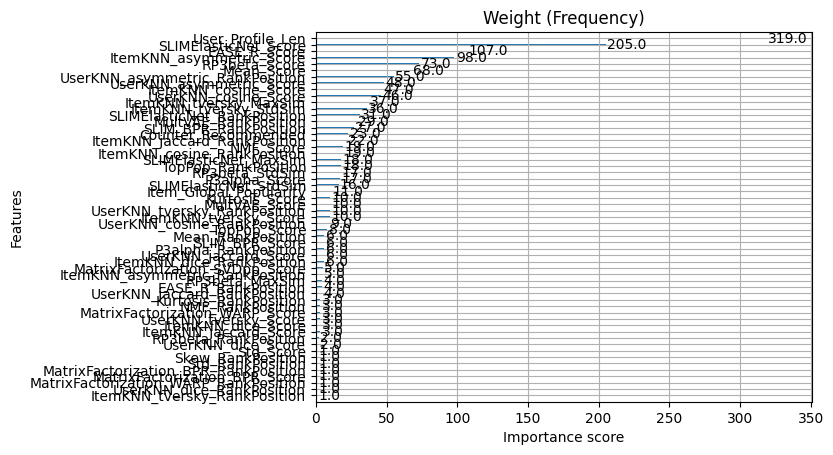

In [20]:
plot_importance(XGB_model, importance_type='weight', title='Weight (Frequency)')